In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df=pd.read_csv('train.csv')
print(df.shape)

(891, 12)


In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# EDA

In [13]:
print(df['Survived'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [14]:
print(df['Survived'].mean())

0.3838383838383838


In [15]:
print(df.groupby('Sex')['Survived'].mean())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [16]:
print(df.groupby('Pclass')['Survived'].mean())

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [17]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


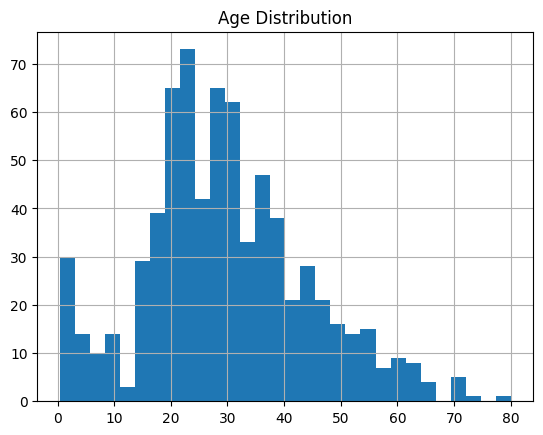

In [18]:
df['Age'].hist(bins=30)
plt.title('Age Distribution')
plt.show()

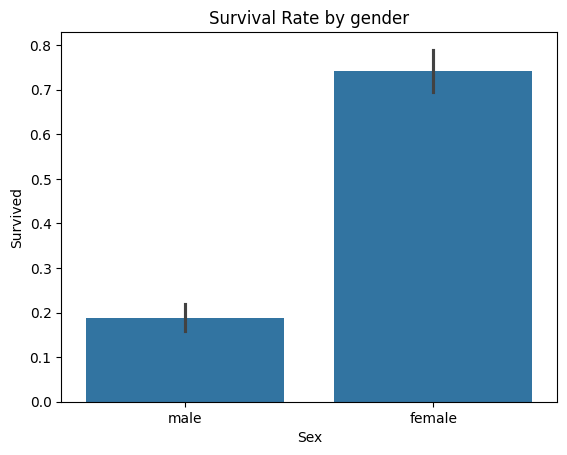

In [19]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by gender')
plt.show()

# Clean and Preprocess

In [45]:
df.fillna(df['Age'].median(), inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",28.0,22.0,1,0,A/5 21171,7.2500,28.0,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",28.0,38.0,1,0,PC 17599,71.2833,28.0,2
2,3,1,3,"Heikkinen, Miss. Laina",28.0,26.0,0,0,STON/O2. 3101282,7.9250,28.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",28.0,35.0,1,0,113803,53.1000,28.0,2
4,5,0,3,"Allen, Mr. William Henry",28.0,35.0,0,0,373450,8.0500,28.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",28.0,27.0,0,0,211536,13.0000,28.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",28.0,19.0,0,0,112053,30.0000,28.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",28.0,28.0,1,2,W./C. 6607,23.4500,28.0,4
889,890,1,1,"Behr, Mr. Karl Howell",28.0,26.0,0,0,111369,30.0000,28.0,1


In [46]:
df.fillna(df['Embarked'].mode()[0], inplace=True)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",28.0,22.0,1,0,A/5 21171,7.2500,28.0,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",28.0,38.0,1,0,PC 17599,71.2833,28.0,2
2,3,1,3,"Heikkinen, Miss. Laina",28.0,26.0,0,0,STON/O2. 3101282,7.9250,28.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",28.0,35.0,1,0,113803,53.1000,28.0,2
4,5,0,3,"Allen, Mr. William Henry",28.0,35.0,0,0,373450,8.0500,28.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",28.0,27.0,0,0,211536,13.0000,28.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",28.0,19.0,0,0,112053,30.0000,28.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",28.0,28.0,1,2,W./C. 6607,23.4500,28.0,4
889,890,1,1,"Behr, Mr. Karl Howell",28.0,26.0,0,0,111369,30.0000,28.0,1


In [52]:
print(df['Sex'].unique())       
print(df['Embarked'].unique())

[28.]
[28.]


In [60]:
df.fillna(df['Embarked'].mode()[0], inplace=True)

df.fillna(df['Age'].median(), inplace=True)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,0,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,0,4
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,0,1


In [61]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [62]:
df['Sex']=le.fit_transform(df['Sex'])
df['Embarked']=le.fit_transform(df['Embarked'])

In [63]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [64]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
dtype: int64


# Feature selection and train test split

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
features=['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize']
X=df[features]
y=df['Survived']

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
print(f'Training samples: {len(X_train)}, Testing samples: {len(X_test)}')

Training samples: 712, Testing samples: 179


# Train the Model

In [70]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=200)
model.fit(X_train, y_train) 
print('model trained successfully')

model trained successfully


In [73]:
y_pred=model.predict(X_test)
print(f'Predictions: {y_pred}')

Predictions: [0 0 0 1 0 1 0 0 0 1 1 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 0 1 0 0 1 0 1 1 1
 0 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 1
 0 1 1 1 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0]


# Evaluate and Interpret

In [76]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.74


In [77]:
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

              precision    recall  f1-score   support

Not Survived       0.73      0.90      0.80       105
    Survived       0.78      0.53      0.63        74

    accuracy                           0.74       179
   macro avg       0.75      0.71      0.72       179
weighted avg       0.75      0.74      0.73       179



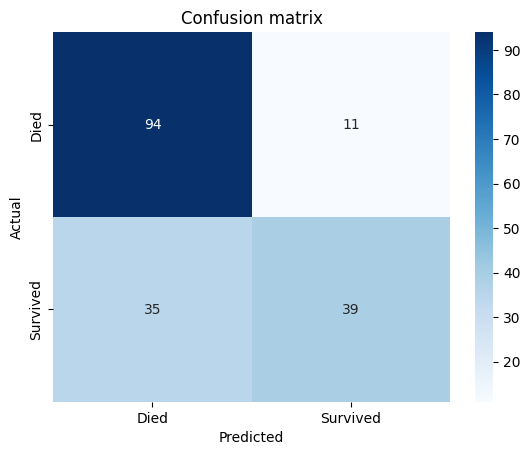

In [78]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.show()

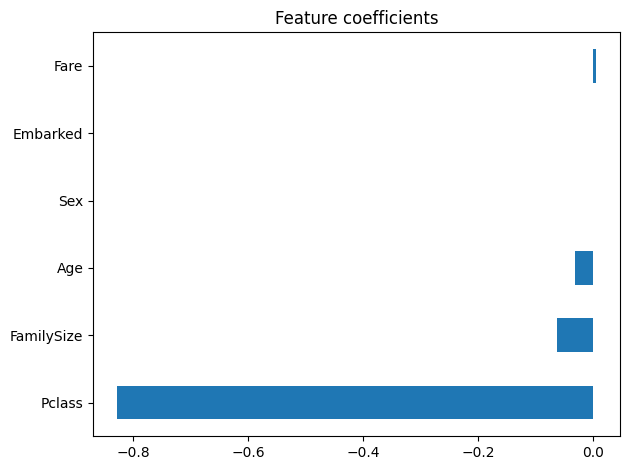

In [79]:
feature_importance = pd.Series(
    model.coef_[0], index=features
).sort_values()
feature_importance.plot(kind='barh', title='Feature coefficients')
plt.tight_layout()
plt.show()